In [1]:
from tinyphysics import TinyPhysicsModel, TinyPhysicsSimulator, CONTROL_START_IDX
from controllers import pid, feedforward_pid, qp
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme()

C:\Users\Kanishk\Desktop\Github Projects\controls_challenge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = TinyPhysicsModel('./models/tinyphysics.onnx', debug=False)

In [3]:
DATA_FILE = './data/00000.csv'

controllers = {
    'pid':             pid.Controller(),
    'feedforward_pid': feedforward_pid.Controller(),
    'qp':              qp.Controller(),
}

results = {}
histories = {}

for name, ctrl in controllers.items():
    print(f'Running {name}...')
    sim = TinyPhysicsSimulator(model, DATA_FILE, controller=ctrl, debug=False)
    cost = sim.rollout()
    results[name] = cost
    histories[name] = list(sim.current_lataccel_history)
    print(f'  lataccel_cost: {cost["lataccel_cost"]:.4f} | jerk_cost: {cost["jerk_cost"]:.4f} | total_cost: {cost["total_cost"]:.4f}')

target_history = sim.target_lataccel_history

Running pid...
  lataccel_cost: 1.0490 | jerk_cost: 31.9399 | total_cost: 84.3906
Running feedforward_pid...
  lataccel_cost: 1.0333 | jerk_cost: 30.2420 | total_cost: 81.9087
Running qp...
  lataccel_cost: 0.8533 | jerk_cost: 31.3292 | total_cost: 73.9952


In [4]:
# Cost comparison table
df = pd.DataFrame(results).T.round(4)
df.index.name = 'controller'
df

,lataccel_cost,jerk_cost,total_cost
controller,,,
pid,1.0490,31.9399,84.3906
feedforward_pid,1.0333,30.2420,81.9087
qp,0.8533,31.3292,73.9952


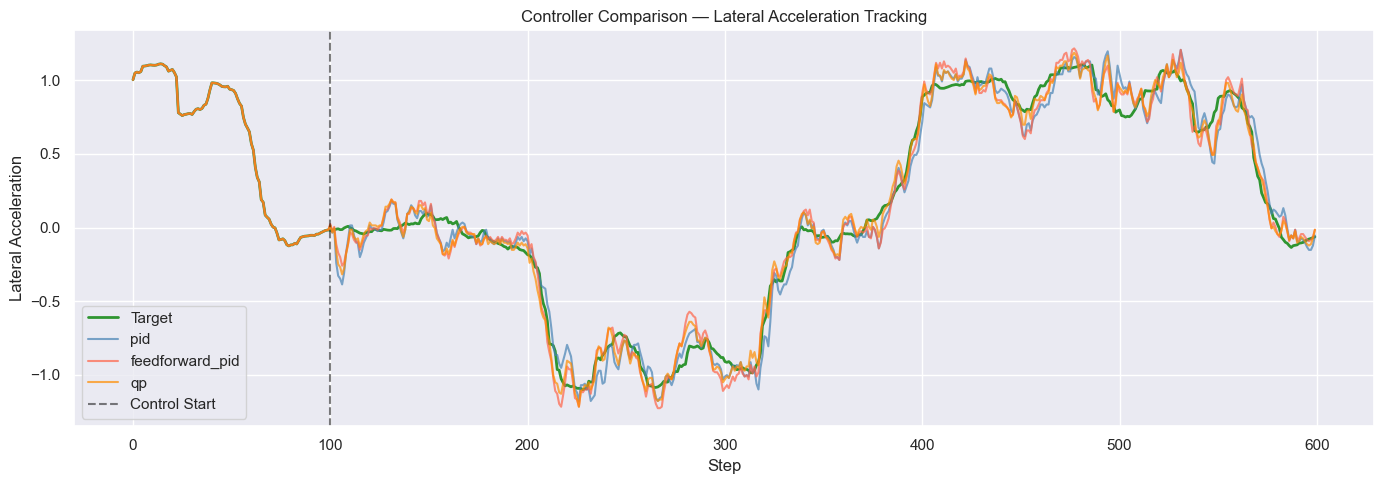

In [5]:
# Lateral acceleration tracking plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(target_history, label='Target', color='green', linewidth=2, alpha=0.8)
colors = ['steelblue', 'tomato', 'darkorange']
for (name, history), color in zip(histories.items(), colors):
    ax.plot(history, label=name, color=color, alpha=0.7)

ax.axvline(x=CONTROL_START_IDX, color='black', linestyle='--', alpha=0.5, label='Control Start')
ax.set_xlabel('Step')
ax.set_ylabel('Lateral Acceleration')
ax.set_title('Controller Comparison — Lateral Acceleration Tracking')
ax.legend()
plt.tight_layout()
plt.show()

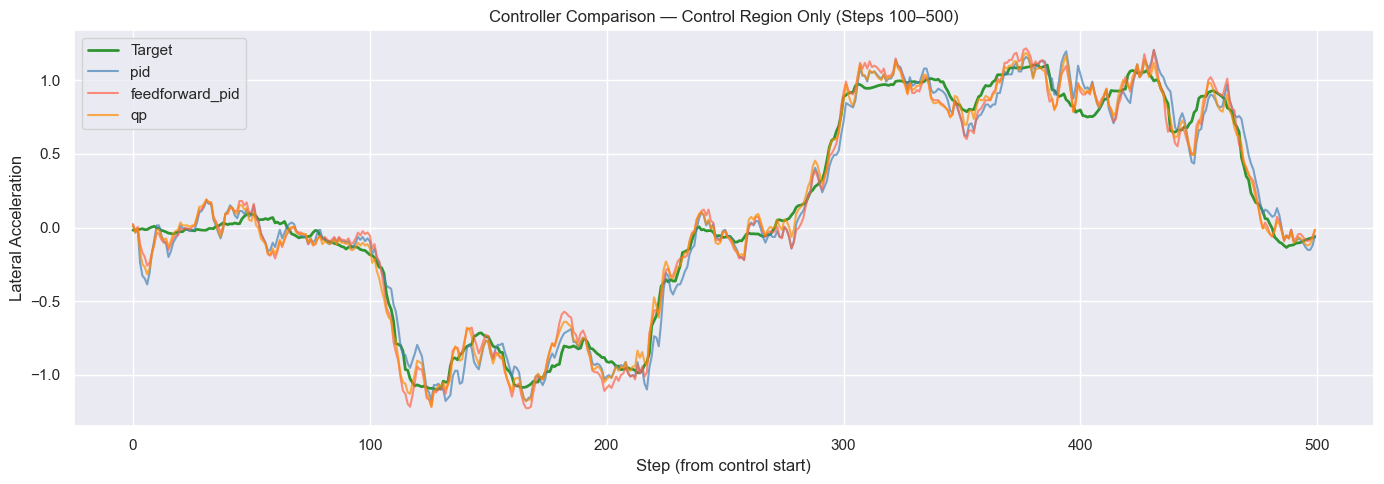

In [6]:
# Zoom in on the control region only (steps 100-500)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(target_history[CONTROL_START_IDX:], label='Target', color='green', linewidth=2, alpha=0.8)
for (name, history), color in zip(histories.items(), colors):
    ax.plot(history[CONTROL_START_IDX:], label=name, color=color, alpha=0.7)

ax.set_xlabel('Step (from control start)')
ax.set_ylabel('Lateral Acceleration')
ax.set_title('Controller Comparison — Control Region Only (Steps 100–500)')
ax.legend()
plt.tight_layout()
plt.show()

## Aggregate comparison over many segments

The single rollout above is just one (easy) segment — per-segment cost is noisy and
segment 00000 scores well below average. The cell below averages each controller
over the first N segments for a representative comparison. Bump `N` for a tighter
estimate (it runs sequentially, so larger N is slower).

In [7]:
import numpy as np
from pathlib import Path

N = 50  # number of segments to average over
files = sorted(Path('./data').iterdir())[:N]

agg = {}
for name, Ctrl in [('pid', pid.Controller),
                   ('feedforward_pid', feedforward_pid.Controller),
                   ('qp', qp.Controller)]:
    costs = []
    for f in files:
        sim = TinyPhysicsSimulator(model, str(f), controller=Ctrl(), debug=False)
        costs.append(sim.rollout())
    cdf = pd.DataFrame(costs)
    agg[name] = {
        'lataccel_cost': cdf['lataccel_cost'].mean(),
        'jerk_cost':     cdf['jerk_cost'].mean(),
        'total_mean':    cdf['total_cost'].mean(),
        'total_median':  cdf['total_cost'].median(),
    }
    print(f"{name:16s} total mean={agg[name]['total_mean']:7.3f}  "
          f"median={agg[name]['total_median']:7.3f}")

agg_df = pd.DataFrame(agg).T.round(3)
agg_df.index.name = f'controller (N={N} segs)'
agg_df

pid              total mean= 69.742  median= 67.182


KeyboardInterrupt: 